In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# load dataset
df = pd.read_csv("pod_gpu_duty_cycle_anon.csv")

In [10]:
# convert timestamp to numeric
df["timestamp_anon"] = pd.to_numeric(df["timestamp_anon"], errors="coerce")

# remove missing timestamps
df = df.dropna(subset=["timestamp_anon"])

# sort the dataframe first by container, and then by time within each container
df = df.sort_values(["container_ip", "timestamp_anon"])

# compute time differences per container
df["sampling_period"] = df.groupby("container_ip")["timestamp_anon"].diff()

# remove Nan values
sampling_periods = df["sampling_period"].dropna()

print("Min sampling period:", sampling_periods.min(), "seconds")
print("Max sampling period:", sampling_periods.max(), "seconds")
print("Median sampling period:", sampling_periods.median(), "seconds")
print("Mean sampling period:", sampling_periods.mean(), "seconds")

Min sampling period: 57.0 seconds
Max sampling period: 35967.0 seconds
Median sampling period: 57.0 seconds
Mean sampling period: 58.79762707122601 seconds


In [5]:
print(sampling_periods.value_counts().head(10))

sampling_period
57.0      154973
171.0       1500
114.0        749
228.0         27
513.0          9
285.0          5
456.0          3
399.0          3
1026.0         1
342.0          1
Name: count, dtype: int64


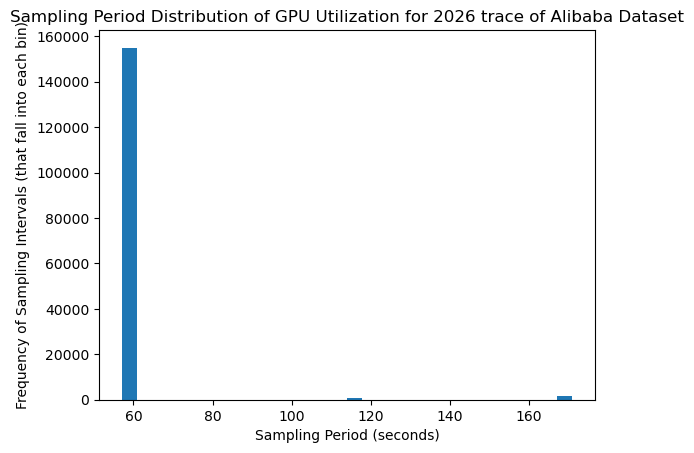

In [ ]:
plt.figure()

#since most of the distribution is concentrated around 200 seconds, I am creating a histogram with a 200 second x axis
filtered = sampling_periods[sampling_periods <= 200]

plt.hist(filtered, bins=30)

plt.xlabel("Sampling Period (seconds)")
plt.ylabel("Frequency of Sampling Intervals (that fall into each bin)")
plt.title("Sampling Period Distribution of GPU Utilization for 2026 trace of Alibaba Dataset")

plt.show()